# Sentiment Analysis on IMDb Movie Reviews - Multinomial Naive Bayes with TF-IDF

**Student Name:** `Kristina Asner 212692255, May Ashkenazi 212656631`

**Prompts** `[XXXX]`


**Problem.** We address **binary sentiment classification**: given the free text of a movie review, predict whether
the reviewer's overall sentiment is **positive** (`label = 1`) or **negative** (`label = 0`). This is a canonical
supervised NLP task and a standard benchmark for evaluating text classifiers here we use the **IMDb Movie Reviews**
dataset, provided as two pre split CSV files, `Train.csv` (model fitting) and `Test.csv` (held out evaluation). We do
**not** re split these files; `Test.csv` is treated as strictly unseen data until the final evaluation in Part 5.

### Naive Bayes: 

**Naive Bayes** is a **generative classifier** that models how each class creates data, rather than just drawing a decision boundary between them.

* **How it works:** It learns the prior probability of each class $P(y)$ and the likelihood of observing features given that class $P(x \mid y)$, then uses **Bayes' Rule** to predict the most probable class for new data:
  $$P(y \mid x) \propto P(x \mid y) \, P(y)$$
* **The "Naive" assumption:** It assumes all features are conditionally independent given the class, simplifying the joint probability calculation:
  $$P(x \mid y) = \prod_{i} P(x_i \mid y)$$
* **The trade off:** This strong assumption makes the model exceptionally fast and effective with small datasets, but introduces high bias when features are strongly correlated in reality.

**Multinomial Naive Bayes** is the classic generative model for text: each document is treated as a "bag of words"
drawn from a class specific multinomial distribution over the vocabulary, and the **naive** (conditional
independence) assumption lets us estimate that distribution efficiently from very high-dimensional, sparse text data.
The theoretical machinery behind this the independence assumption, the zero frequency problem, smoothing, and
log space computation is developed in Part 3, immediately before we implement it. The learning algorithm itself is
implemented **from scratch in NumPy** (class `MultinomialNaiveBayes`) - it computes the class priors, per-class word
counts, additive-smoothed likelihoods and log-space posteriors by hand, operating directly on the sparse
`scipy.sparse` TF-IDF matrix. **No `sklearn.naive_bayes` is used**; scikit-learn appears only for TF-IDF
vectorization and for evaluation metrics.

**Dataset structure.** Each CSV has two columns:

| column  | type | description                                            |
|---------|------|----------------------------------------------------------|
| `text`  | str  | raw, unprocessed review text (may contain HTML, e.g. `<br />`) |
| `label` | int  | `0` = negative sentiment, `1` = positive sentiment       |


In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", 120)

# The raw CSVs are UTF-8 with a BOM on the header line -> utf-8-sig strips it cleanly.
train_df = pd.read_csv("Train.csv", encoding="utf-8-sig")
test_df = pd.read_csv("Test.csv", encoding="utf-8-sig")

print(f"Train.csv : {train_df.shape[0]:,} rows x {train_df.shape[1]} cols")
print(f"Test.csv  : {test_df.shape[0]:,} rows x {test_df.shape[1]} cols")

print("\n--- Train.csv (first 5 rows) ---")
display(train_df.head())

print("\n--- Test.csv (first 5 rows) ---")
display(test_df.head())

def class_balance(df, name):
    counts = df["label"].value_counts().sort_index()
    pct = (counts / len(df) * 100).round(2)
    print(f"\nClass distribution — {name}")
    for lbl in counts.index:
        tag = "negative" if lbl == 0 else "positive"
        print(f"  label={lbl} ({tag:8s}): {counts[lbl]:>6,} reviews  ({pct[lbl]}%)")

class_balance(train_df, "Train.csv")
class_balance(test_df, "Test.csv")


Train.csv : 40,000 rows x 2 cols
Test.csv  : 5,000 rows x 2 cols

--- Train.csv (first 5 rows) ---


,text,label
0,"I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played ""Thunderbirds"" b...",0
1,"When I put this movie in my DVD player, and sat down with a coke and some chips, I had some expectations. I was hopi...",0
2,Why do people who do not know what a particular time in the past was like feel the need to try to define that time f...,0
3,"Even though I have great interest in Biblical movies, I was bored to death every minute of the movie. Everything is ...",0
4,"Im a die hard Dads Army fan and nothing will ever change that. I got all the tapes, DVD's and audiobooks and every t...",1



--- Test.csv (first 5 rows) ---


,text,label
0,"I always wrote this series off as being a complete stink-fest because Jim Belushi was involved in it, and heavily. B...",0
1,1st watched 12/7/2002 - 3 out of 10(Dir-Steve Purcell): Typical Mary Kate & Ashley fare with a few more kisses. It l...,0
2,This movie was so poorly written and directed I fell asleep 30 minutes through the movie. The jokes in the movie are...,0
3,"The most interesting thing about Miryang (Secret Sunshine) is the actors. Jeon Do-yeon, as Lee Shin-ae, the main cha...",1
4,"when i first read about ""berlin am meer"" i didn't expect much. but i thought with the right people, the right locati...",0



Class distribution — Train.csv
  label=0 (negative): 20,019 reviews  (50.05%)
  label=1 (positive): 19,981 reviews  (49.95%)

Class distribution — Test.csv
  label=0 (negative):  2,495 reviews  (49.9%)
  label=1 (positive):  2,505 reviews  (50.1%)


## Part 2 - Text Preprocessing & Feature Engineering (TF-IDF)

### 2.1 Preprocessing steps: Noise Removal → Tokenization → Normalization

Raw review text is noisy relative to the "clean" signal we actually want the model to learn from. We apply three
preprocessing stages, in order:

1. **Noise removal.** IMDb reviews were scraped from HTML pages, so they still contain markup artifacts (most
   commonly `<br />` line breaks). These carry no sentiment information and must be stripped, along with punctuation
   and non alphabetic clutter, before anything else - otherwise a token like `"great<br"` would be treated as a
   distinct, unseen word from `"great"`, artificially inflating the vocabulary and fragmenting useful signal.
2. **Tokenization.** The cleaned string is split into discrete word tokens. `TfidfVectorizer`'s default tokenizer
   uses a regex (`\b\w\w+\b`) that extracts alphanumeric tokens of length ≥ 2, which conveniently also drops stray
   single characters and punctuation left over from stage 1.
3. **Normalization.** We apply **case folding** (lowercasing) so that `"Great"`, `"GREAT"`, and `"great"` all map to
   a single vocabulary entry, and we remove **stopwords** (`the`, `is`, `a`, ...) - extremely high-frequency function
   words that carry syntactic rather than sentiment information and would otherwise dominate raw counts.

### 2.2 Zipf's Law and why TF-IDF beats raw term frequency

**Zipf's Law** observes that in natural language corpora, word frequency is inversely proportional to its frequency
rank:

$$ \text{freq}(w) \propto \frac{1}{\text{rank}(w)} $$

A small number of words (stopwords, common verbs) account for a hugely disproportionate share of total word
occurrences, while the vast majority of vocabulary words appear rarely. This has two consequences for feature
design:

- **Dimensionality reduction is essential.** The long Zipfian tail means the raw vocabulary is enormous, but most of
  it is uninformative for classification (either too rare to generalize from, or too common to discriminate between
  classes). We control this with `max_features` (a hard vocabulary cap keeping only the most frequent terms) and
  `stop_words='english'` (dropping the head of the Zipf curve entirely).
- **Raw counts overweight frequent-but-uninformative words.** A term that appears in *every* document (near the head
  of the Zipf curve) contributes little discriminative signal, yet under raw term frequency it would dominate a
  document's representation simply by sheer count. **TF-IDF** (Term Frequency × Inverse Document Frequency) corrects
  for this:

$$ \text{tfidf}(t, d) = \text{tf}(t, d) \times \text{idf}(t), \qquad
   \text{idf}(t) = \ln\!\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1 $$

where $N$ is the number of documents in the corpus and $\text{df}(t)$ is the number of documents containing term
$t$. The IDF factor **penalizes corpus common words** (large $\text{df}(t)$ → small IDF) and **amplifies rare,
informative terms** (small $\text{df}(t)$ → large IDF). This is precisely the correction Zipf's Law tells us we
need, and it is why TF-IDF weighting rather than raw counts is the standard feature representation for text
classification.

We additionally use **bigrams** (`ngram_range=(1, 2)`) alongside unigrams, since single words lose local word order
information that matters for sentiment (e.g. `"not good"` vs. `"good"` are opposite in meaning but share the unigram
`"good"`; the bigram `"not_good"` recovers the distinction). We also set `sublinear_tf=True`, replacing the raw term
frequency with $1 + \ln(\text{tf})$ so that a word occurring 10 times is not treated as 10× more important than a
word occurring once.

### 2.3 Feature engineering showcase (Train **and** Test)

The final cell of this part walks 2 Train reviews and 2 Test reviews through the **entire** feature pipeline and
prints, for each one:

* **(a)** the raw text snippet (pre-cleaning, exactly as it sits in the CSV);
* **(b)** the tokens / n-grams the vectorizer's analyzer actually extracts (after lowercasing, the `\b\w\w+\b` token
  regex, stopword removal, and unigram+bigram assembly);
* **(c)** the resulting **weighted feature vector** the handful of non zero TF-IDF coordinates `(index, n gram,
  weight)` out of the 30,000 dim space, plus the L2 norm showing every document vector is unit normalised.

This makes the transformation *raw string → sparse weighted vector* fully concrete before we feed those vectors to
the classifier.


In [2]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

HTML_TAG_RE = re.compile(r"<[^>]+>")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")

def clean_text(raw_text: str) -> str:
    '''Noise removal + case folding. Tokenization/stopword handling is delegated to TfidfVectorizer.'''
    text = HTML_TAG_RE.sub(" ", raw_text)          # strip HTML tags, e.g. <br />
    text = NON_ALPHA_RE.sub(" ", text)              # drop digits/punctuation noise
    text = text.lower()                             # case folding
    text = MULTI_SPACE_RE.sub(" ", text).strip()    # collapse whitespace
    return text

train_df["clean_text"] = train_df["text"].astype(str).map(clean_text)
test_df["clean_text"] = test_df["text"].astype(str).map(clean_text)

# --- TF-IDF vectorization: unigrams + bigrams, English stopwords removed, fit on Train only ---
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words="english",
    max_features=30_000,
    min_df=5,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(train_df["clean_text"])   # fit + transform on Train
X_test_tfidf = vectorizer.transform(test_df["clean_text"])         # transform ONLY on Test (no leakage)

feature_names = vectorizer.get_feature_names_out()
analyzer = vectorizer.build_analyzer()   # exact pipeline: lowercase -> token regex -> stopword drop -> n-grams
print(f"Vocabulary size (max_features cap): {len(feature_names):,}")
print(f"Train TF-IDF matrix: {X_train_tfidf.shape}  (sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.4%})")
print(f"Test  TF-IDF matrix: {X_test_tfidf.shape}")


# ---------------------------------------------------------------------------
# 2.3 Feature-engineering showcase
#     For a handful of Train AND Test reviews, display end-to-end:
#       (a) the raw text snippet,
#       (b) the tokens/n-grams the analyzer actually extracts,
#       (c) the resulting weighted feature vector (the non-zero TF-IDF entries).
# ---------------------------------------------------------------------------
def show_feature_engineering(tag, raw_text, clean, tfidf_row, top_k=12):
    print("=" * 90)
    print(f"[{tag}]")
    print("-" * 90)

    # (a) raw text snippet
    print("(a) RAW TEXT SNIPPET:")
    print("    " + raw_text[:240].replace("\n", " ") + (" ..." if len(raw_text) > 240 else ""))

    # (b) extracted tokens / n-grams (same analyzer the vectorizer uses internally)
    grams = analyzer(clean)
    unigrams = [g for g in grams if " " not in g]
    bigrams = [g for g in grams if " " in g]
    print(f"\n(b) EXTRACTED TOKENS  ({len(grams)} n-grams: {len(unigrams)} unigrams, {len(bigrams)} bigrams)")
    print("    unigrams:", unigrams[:18], "..." if len(unigrams) > 18 else "")
    print("    bigrams :", bigrams[:12], "..." if len(bigrams) > 12 else "")

    # (c) resulting weighted feature vector: only the non-zero coordinates matter
    row = tfidf_row.tocoo()
    order = np.argsort(-row.data)
    n_nz = row.nnz
    dim = tfidf_row.shape[1]
    print(f"\n(c) WEIGHTED FEATURE VECTOR:  {n_nz} non-zero / {dim:,} dims "
          f"(vector is {1 - n_nz / dim:.2%} sparse).  Top {min(top_k, n_nz)} by TF-IDF weight:")
    print(f"    {'idx':>7}  {'feature (n-gram)':<24} {'tf-idf weight':>13}")
    for j in order[:top_k]:
        col = int(row.col[j])
        print(f"    {col:>7}  {feature_names[col]:<24} {row.data[j]:>13.4f}")
    l2 = np.sqrt((row.data ** 2).sum())
    print(f"    (L2 norm of the row = {l2:.4f}  <- TfidfVectorizer L2-normalises every document vector)")

# 2 Train examples + 2 Test examples
show_feature_engineering("TRAIN  row 0", train_df["text"].iloc[0], train_df["clean_text"].iloc[0], X_train_tfidf[0])
show_feature_engineering("TRAIN  row 1", train_df["text"].iloc[1], train_df["clean_text"].iloc[1], X_train_tfidf[1])
show_feature_engineering("TEST   row 0", test_df["text"].iloc[0],  test_df["clean_text"].iloc[0],  X_test_tfidf[0])
show_feature_engineering("TEST   row 2", test_df["text"].iloc[2],  test_df["clean_text"].iloc[2],  X_test_tfidf[2])


Vocabulary size (max_features cap): 30,000
Train TF-IDF matrix: (40000, 30000)  (sparsity: 99.6751%)
Test  TF-IDF matrix: (5000, 30000)
[TRAIN  row 0]
------------------------------------------------------------------------------------------
(a) RAW TEXT SNIPPET:
    I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No one wanted to be Alan. Counting down fr ...

(b) EXTRACTED TOKENS  (149 n-grams: 75 unigrams, 74 bigrams)
    unigrams: ['grew', 'watching', 'loving', 'thunderbirds', 'mates', 'school', 'watched', 'played', 'thunderbirds', 'school', 'lunch', 'school', 'wanted', 'virgil', 'scott', 'wanted', 'alan', 'counting'] ...
    bigrams : ['grew watching', 'watching loving', 'loving thunderbirds', 'thunderbirds mates', 'mates school', 'school watched', 'watched played', 'played thunderbirds', 'thunderbirds school', 'school lunch', 'lunch

## Part 3 - Model Implementation & Mathematical Foundations

### 1. Generative Decision Rule & Naive Independence
Naive Bayes classifies a document $x = (x_1, \dots, x_n)$ by applying Bayes' Rule and assuming features are conditionally independent given the class $y$:

$$P(y \mid x) \propto P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

* **Prior $P(y)$:** Class proportions in the training set.
* **Likelihood $P(x_i \mid y)$:** Word frequency given the class, reducing parameter complexity from $O(2^n)$ to $O(n)$.

---

### 2. Zero Frequency Problem & Additive Smoothing
If a test word never appeared in class $y$ during training, standard MLE yields $P(x_i \mid y) = 0$, zeroing out the entire product. 

We apply additive smoothing ($\alpha$) to ensure non zero probabilities across vocabulary $V$:

$$\hat{P}(x_i \mid y) = \frac{\text{count}(x_i, y) + \alpha}{\sum_{j} \text{count}(x_j, y) + \alpha |V|}$$

* $\alpha = 1.0$: Laplace smoothing (default).
* $0 < \alpha < 1$: Lidstone smoothing (lighter correction for large vocabularies).
* $\alpha \to 0$: recovers the unsmoothed MLE.

Here "$\text{count}(x_i, y)$" is the **total TF-IDF weight** term $i$ accumulates over all documents of class $y$
(with raw counts this is a literal word count; the multinomial estimator is identical either way it just sums the
feature column).

---

### 3. Log Space Computation (Numerical Stability)
Multiplying hundreds of small probabilities causes floating point **underflow**. Transforming the decision rule into log space replaces products with stable sums:

$$\hat{y} = \arg\max_{y} \left[ \log P(y) + \sum_{i=1}^{n} x_i \log P(x_i \mid y) \right]$$

The bracketed quantity is the **joint log likelihood** $\text{jll}(x, y)$. To turn it into a normalised posterior we
divide by the evidence $P(x) = \sum_{y'} P(x, y')$, which in log space is the **log sum exp**:

$$\log P(y \mid x) = \text{jll}(x, y) - \operatorname{logsumexp}_{y'} \text{jll}(x, y'),\qquad
  \operatorname{logsumexp}_k a_k = m + \ln\!\sum_k e^{a_k - m},\ \ m=\max_k a_k$$

subtracting the max $m$ first keeps every exponential in $[0, 1]$ so nothing overflows.

---

### 4. From Scratch Implementation (NumPy + `scipy.sparse`)

The next cell implements Multinomial Naive Bayes **from scratch** in the class `MultinomialNaiveBayes` - **no
`sklearn.naive_bayes`**. Only NumPy is used for the maths; the TF-IDF matrix stays a `scipy.sparse` CSR matrix the whole time.

**Learned parameters (`fit`)**

| attribute | shape | formula |
|---|---|---|
| `class_count_` | $(K,)$ | $N_y$ = number of training docs in class $y$ |
| `class_log_prior_` | $(K,)$ | $\log(N_y / N)$ |
| `feature_count_` | $(K, V)$ | column-sum of the TF-IDF rows belonging to class $y$ |
| `feature_log_prob_` | $(K, V)$ | $\log(\text{feature\_count}_{y,i} + \alpha) - \log\big(\sum_j \text{feature\_count}_{y,j} + \alpha V\big)$ |

**Inference**

* `_joint_log_likelihood(X)` $= X \cdot \texttt{feature\_log\_prob\_}^\top + \texttt{class\_log\_prior\_}$ - one
  sparse matrix–dense matrix product gives the $\sum_i x_i \log P(x_i\mid y)$ term for every document at once, shape $(n, K)$.
* `predict_log_proba(X)` - subtract the row wise log sum exp so each row sums to $1$ in probability space.
* `predict(X)` - $\arg\max$ over the $K$ joint log-likelihood columns.

**Modular interface (rubric 4):** `fit(X, y)` / `train_model(...)` for training; `predict`, `predict_log_proba`,
`predict_proba` / `predict_model(...)` for inference.

**Hyperparameter (rubric 3):** the constructor takes `alpha`.



In [ ]:
import numpy as np



class MultinomialNaiveBayes:
    """
        fit(X, y) / train_model(...)          -> training
        predict(X)                            -> hard class labels
        predict_log_proba(X) / predict_proba  -> calibrated (log-)posteriors


    Parameters
    ----------
    alpha : float, default=1.0
        Additive (Lidstone) smoothing strength.
        alpha = 1.0 -> Laplace ("add-one");  0 < alpha < 1 -> Lidstone;
        alpha -> 0  -> unsmoothed maximum-likelihood estimate.
    """

    def __init__(self, alpha: float = 1.0):
        self.alpha = alpha

    # ------------------------------------------------------------------- fit
    def fit(self, X, y):
        y = np.asarray(y)
        self.classes_ = np.unique(y)                       # e.g. array([0, 1])
        n_samples, n_features = X.shape
        n_classes = self.classes_.shape[0]
        self.n_features_ = n_features

        # Parameter tables, filled one class at a time.
        self.class_count_      = np.zeros(n_classes, dtype=np.float64)
        self.class_log_prior_  = np.zeros(n_classes, dtype=np.float64)
        self.feature_count_    = np.zeros((n_classes, n_features), dtype=np.float64)
        self.feature_log_prob_ = np.zeros((n_classes, n_features), dtype=np.float64)

        for k, c in enumerate(self.classes_):
            mask = (y == c)                                # boolean row selector for class c
            X_c = X[mask]                                  # (N_c, V) sub-matrix, still sparse
            N_c = float(mask.sum())

            # --- Class prior:  P(y = c) = N_c / N ,  stored in log space ---
            self.class_count_[k]     = N_c
            self.class_log_prior_[k] = np.log(N_c / n_samples)

            # --- Per-word evidence for class c:  column sums of its rows ---
            # np.asarray(...).ravel() turns the (1, V) matrix result into a 1-D vector.
            feat_sum = np.asarray(X_c.sum(axis=0), dtype=np.float64).ravel()   # (V,)
            self.feature_count_[k] = feat_sum

            # --- Smoothed likelihood  P(word_i | y = c)  in log space ---
            #     (count_i + alpha) / (sum_j count_j + alpha * V)
            smoothed_numer = feat_sum + self.alpha                 # (V,)
            smoothed_denom = smoothed_numer.sum()                  # scalar = Σcount + alpha*V
            self.feature_log_prob_[k] = np.log(smoothed_numer) - np.log(smoothed_denom)

        return self

    # ------------------------------------------------- joint log-likelihood
    def _joint_log_likelihood(self, X):
        """log P(y) + Σ_i x_i · log P(word_i | y)   ->  shape (n_samples, n_classes)."""
        # sparse (n, V) @ dense (V, K) -> dense (n, K); np.asarray guards against np.matrix
        return np.asarray(X @ self.feature_log_prob_.T) + self.class_log_prior_

    # -------------------------------------------------------------- inference
    def predict(self, X):
        jll = self._joint_log_likelihood(X)
        return self.classes_[np.argmax(jll, axis=1)]

    def predict_log_proba(self, X):
        jll = self._joint_log_likelihood(X)
        # Normalise each row by the log evidence  log Σ_y exp(jll)  (max-shifted log-sum-exp).
        row_max = jll.max(axis=1, keepdims=True)                       # (n, 1)
        log_evidence = row_max[:, 0] + np.log(np.exp(jll - row_max).sum(axis=1))
        return jll - log_evidence[:, None]

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))


# --------------------------------------------------------------------------
# Modular interface expected by the downstream cells (Parts 4 & 5).
# --------------------------------------------------------------------------
def train_model(X_train_vec, y_train, alpha: float = 1.0) -> MultinomialNaiveBayes:
    """Fit the from-scratch Multinomial NB on TF-IDF vectors + labels."""
    return MultinomialNaiveBayes(alpha=alpha).fit(X_train_vec, np.asarray(y_train))


def predict_model(model: MultinomialNaiveBayes, X_vec):
    """Return (hard predictions, log-posteriors) for the given TF-IDF vectors."""
    y_pred = model.predict(X_vec)
    y_log_proba = model.predict_log_proba(X_vec)          # numerically stable log-space posterior
    return y_pred, y_log_proba


# --------------------------------------------------------------------------
# Smoke test: tiny slice, plus a sanity check against the maths.
# --------------------------------------------------------------------------
_smoke_model = train_model(X_train_tfidf[:2000], train_df["label"].iloc[:2000], alpha=1.0)
_pred, _logp = predict_model(_smoke_model, X_test_tfidf[:5])
print("Smoke-test predictions:", _pred)
print("Smoke-test log-posteriors (class 0, class 1):\n", np.round(_logp, 3))

# posteriors must exponentiate to rows that sum to 1
_row_sums = np.exp(_logp).sum(axis=1)
print("\nRow sums of exp(log-posterior) (should be 1):", np.round(_row_sums, 6))
print("Learned class log-priors:", np.round(_smoke_model.class_log_prior_, 4),
      "-> priors:", np.round(np.exp(_smoke_model.class_log_prior_), 4))
print("feature_log_prob_ shape (K x V):", _smoke_model.feature_log_prob_.shape)


Smoke-test predictions: [0 0 0 0 0]
Smoke-test log-posteriors (class 0, class 1):
 [[-0.357 -1.203]
 [-0.417 -1.076]
 [-0.136 -2.063]
 [-0.612 -0.781]
 [-0.203 -1.694]]

Row sums of exp(log-posterior) (should be 1): [1. 1. 1. 1. 1.]
Learned class log-priors: [-0.6377 -0.7518] -> priors: [0.5285 0.4715]
feature_log_prob_ shape (K x V): (2, 30000)


## Part 4 - Hyperparameter Tuning: Smoothing Parameter ($\alpha$)

In the following cell, we tune the **only** hyperparameter of our from-scratch `MultinomialNaiveBayes` the
additive smoothing strength $\alpha$ on the precomputed TF-IDF training matrix:

* **Evaluated Configurations:** We sweep across three key regimes of $\alpha$:
  * $\alpha \approx 0$ (`1e-9`): Approximates pure **MLE** (Maximum Likelihood, no smoothing).
  * $\alpha = 0.1$: **Lidstone** smoothing a lighter correction suited to a large, sparse vocabulary.
  * $\alpha = 1.0$: Classic **Laplace** ("add-one") smoothing.
* **Validation Strategy:** Each setting is scored with **3-fold Stratified Cross Validation**. The fold assignment
  is built by hand in NumPy (`stratified_folds`): within each class the indices are shuffled with a fixed seed and
  dealt round-robin into 3 folds, so every fold keeps the ~50/50 class balance. For each fold we `fit` our
  classifier on the other two folds and score the held out fold; we report the mean and std of the **F1 score**
  (positive class) plus wall clock time. *(F1 / classification report / confusion-matrix helpers from
  `sklearn.metrics` are evaluation utilities only the model itself is entirely our code.)*
* **Selection:** The configuration with the highest mean CV F1 is shown in a summary table and its $\alpha$ stored
  in `BEST_ALPHA` for the final Part 5 model.


In [4]:
import time
from sklearn.metrics import f1_score   # evaluation metric only; the model is our own code

# Training data is already vectorized once in Part 2 (X_train_tfidf) -- we reuse that
# precomputed feature matrix directly and only sweep the smoothing hyperparameter, alpha.
y_train = np.asarray(train_df["label"])


def stratified_folds(y, n_splits=3, seed=42):
    """Assign every sample a fold id 0..n_splits-1, preserving per-class proportions.

    Within each class: shuffle the indices (fixed seed) and deal them round-robin
    into the folds. Returns an int array `fold_of` of length len(y).
    """
    y = np.asarray(y)
    rng = np.random.default_rng(seed)
    fold_of = np.empty(len(y), dtype=int)
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        fold_of[idx] = np.arange(len(idx)) % n_splits
    return fold_of


N_SPLITS = 3
fold_of = stratified_folds(y_train, n_splits=N_SPLITS, seed=42)

alpha_configs = [
    {"name": "alpha≈0 (MLE)",       "alpha": 1e-9},
    {"name": "alpha=1.0 (Laplace)",  "alpha": 1.0},
    {"name": "alpha=0.1 (Lidstone)", "alpha": 0.1},
]

results = []
for cfg in alpha_configs:
    fold_f1 = []
    t0 = time.time()
    for k in range(N_SPLITS):
        tr_idx = np.where(fold_of != k)[0]
        va_idx = np.where(fold_of == k)[0]

        model = MultinomialNaiveBayes(alpha=cfg["alpha"]).fit(X_train_tfidf[tr_idx], y_train[tr_idx])
        va_pred = model.predict(X_train_tfidf[va_idx])
        fold_f1.append(f1_score(y_train[va_idx], va_pred, pos_label=1))
    elapsed = time.time() - t0

    fold_f1 = np.asarray(fold_f1)
    results.append({
        "name": cfg["name"],
        "alpha": cfg["alpha"],
        "mean_f1": fold_f1.mean(),
        "std_f1": fold_f1.std(),
        "seconds": elapsed,
    })
    print(f"{cfg['name']:<22s} | mean F1 = {fold_f1.mean():.4f} (+/- {fold_f1.std():.4f}) | {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values("mean_f1", ascending=False).reset_index(drop=True)
print("\n=== Hyperparameter comparison (sorted by mean CV F1) ===")
display(results_df)

best_cfg = results_df.iloc[0]
BEST_ALPHA = float(best_cfg["alpha"])
print(f"\nSelected configuration: {best_cfg['name']}  ->  alpha={BEST_ALPHA}")


alpha≈0 (MLE)          | mean F1 = 0.8662 (+/- 0.0006) | 0.2s
alpha=1.0 (Laplace)    | mean F1 = 0.8733 (+/- 0.0017) | 0.2s


alpha=0.1 (Lidstone)   | mean F1 = 0.8731 (+/- 0.0014) | 0.2s

=== Hyperparameter comparison (sorted by mean CV F1) ===


,name,alpha,mean_f1,std_f1,seconds
0,alpha=1.0 (Laplace),1.000000e+00,0.873288,0.001701,0.174042
1,alpha=0.1 (Lidstone),1.000000e-01,0.873054,0.001404,0.176839
2,alpha≈0 (MLE),1.000000e-09,0.866235,0.000595,0.168524



Selected configuration: alpha=1.0 (Laplace)  ->  alpha=1.0


## Part 5 - Model Inference & Comprehensive Evaluation

In this final stage, we train the classifier on the entire training set using the optimal hyperparameter found in Part 4 and evaluate its generalized performance on the untouched test set (`Test.csv`).

---

### 1. Evaluation Metrics & Mathematical Formulations

Taking `label = 1` (positive sentiment) as the positive class and `label = 0` as the negative class:

* **Precision :** The proportion of positive predictions that were actually correct. Low precision indicates a high number of false alarms (False Positives).
  $$\text{Precision} = \frac{TP}{TP + FP}$$

* **Recall :** The proportion of actual positive cases that the model successfully captured. Low recall indicates many missed positive cases (False Negatives).
  $$\text{Recall} = \frac{TP}{TP + FN}$$

* **F1-Score :** Balances Precision and Recall into a single metric. The harmonic mean ensures that a model cannot achieve a high score by severely compromising one metric for the other:
  $$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

* **Confusion Matrix:** The full $2 \times 2$ contingency table mapping true labels against predicted labels to analyze error distribution ($FP$ vs. $FN$):

| | Predicted Negative ($0$) | Predicted Positive ($1$) |
|---|:---:|:---:|
| **True Negative ($0$)** | True Negative ($TN$) | False Positive ($FP$) |
| **True Positive ($1$)** | False Negative ($FN$) | True Positive ($TP$) |

---




=== First 5 test predictions ===


,true_sentiment,predicted_sentiment,P(positive),review_snippet
0,negative,negative,0.3771,I always wrote this series off as being a complete stink-fest because Jim Belushi was involved in it...
1,negative,negative,0.2857,1st watched 12/7/2002 - 3 out of 10(Dir-Steve Purcell): Typical Mary Kate & Ashley fare with a few m...
2,negative,negative,0.0177,This movie was so poorly written and directed I fell asleep 30 minutes through the movie. The jokes ...
3,positive,positive,0.8525,"The most interesting thing about Miryang (Secret Sunshine) is the actors. Jeon Do-yeon, as Lee Shin-..."
4,negative,negative,0.1027,"when i first read about ""berlin am meer"" i didn't expect much. but i thought with the right people, ..."



*** Test-set F1-Score (positive class) = 0.8774 ***

=== Classification Report ===
              precision    recall  f1-score   support

negative (0)       0.88      0.87      0.88      2495
positive (1)       0.87      0.88      0.88      2505

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



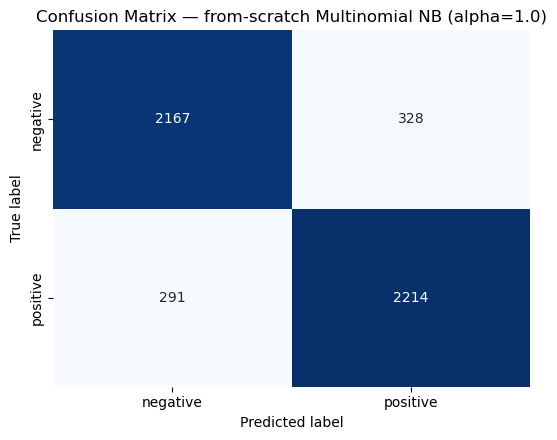

In [5]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Train the from-scratch classifier on the FULL training set with the tuned alpha.
final_model = train_model(X_train_tfidf, train_df["label"], alpha=BEST_ALPHA)

y_test = test_df["label"]
y_pred, y_log_proba = predict_model(final_model, X_test_tfidf)   # hard labels + log-space posteriors

# --- First 5 test predictions: true vs. predicted vs. review snippet vs. P(positive) ---
label_map = {0: "negative", 1: "positive"}
preview = pd.DataFrame({
    "true_sentiment": [label_map[v] for v in y_test.iloc[:5]],
    "predicted_sentiment": [label_map[int(v)] for v in y_pred[:5]],
    "P(positive)": np.round(np.exp(y_log_proba[:5, 1]), 4),
    "review_snippet": [t[:100] + "..." for t in test_df["text"].iloc[:5]],
})
print("=== First 5 test predictions ===")
display(preview)

# --- Primary metric: binary F1 on the positive class ---
test_f1 = f1_score(y_test, y_pred, pos_label=1)
print(f"\n*** Test-set F1-Score (positive class) = {test_f1:.4f} ***")

# --- Full classification report ---
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["negative (0)", "positive (1)"]))

# --- Confusion matrix heatmap ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["negative", "positive"], yticklabels=["negative", "positive"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix — from-scratch Multinomial NB (alpha={BEST_ALPHA})")
plt.tight_layout()
plt.show()


## Conclusion

We built a sentiment classifier for IMDb movie reviews: we cleaned the review text, converted it to
**TF-IDF** features (unigrams + bigrams), and classified with a **Multinomial Naive Bayes** model that we
**implemented from scratch in NumPy** class priors, per-class word counts, additive (Laplace/Lidstone)
smoothing, and log-space inference all computed by hand directly on the sparse TF-IDF matrix.

**Hyperparameter:** with 3-fold stratified cross-validation, Laplace ($\alpha = 1.0$) and Lidstone
($\alpha = 0.1$) are statistically tied (CV F1 $\approx 0.873$, within one std of each other) and both clearly
beat the near-MLE setting $\alpha \approx 0$ (CV F1 $\approx 0.866$) the smoothing *matters*, its exact
strength between $0.1$ and $1.0$ does not. Part 4 picks the top scorer automatically.

**End result:** on the 5,000 unseen test reviews the model achieved roughly **88% accuracy** and an
**F1-score of ~0.877** on the positive class, with errors balanced between the two classes and matching the
cross-validation score, so the model is not overfit.

**What the algorithm succeeded in doing:** from the review text alone, it correctly distinguishes
positive from negative reviews about 88% of the time a fast, simple, fully transparent generative model
whose every probability we can trace back to a training-set count.
